# IE410 - Advanced Computer Programming
# Study-2: Model Selection and Setup (Before Training)

**Student:** Ibrahim Hakki Keles  
**Project:** Diabetes Prediction (CDC Health Indicators)  
**Date:** May 2026

---

## Methodology
Our model selection follows a **systematic 4-step process:**
1. **Screen** 6 candidate models on a small sample (quick baseline)
2. **Eliminate** underperforming models with data-driven justification
3. **Tune** the top 3 models with GridSearchCV (best hyperparameters)
4. **Compare** tuned models fairly — select the best for Study-3

## 1. Importing Libraries

In [ ]:
# --- Kutuphaneleri Yukleme ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
# 6 Aday Model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print("Kutuphaneler yuklendi!")

Kutuphaneler yuklendi!


## 2. Loading Dataset and Quick Recap

In [ ]:
# --- Veriyi Yukleme ---
df = pd.read_csv('../data/raw/cdc_diabetes_health_indicators.csv')
print(f"Veri Seti: {df.shape[0]:,} satir x {df.shape[1]} sutun")

# Hedef degisken
target_counts = df['Diabetes_binary'].value_counts()
target_pct = df['Diabetes_binary'].value_counts(normalize=True) * 100
print(f"\nDiyabet Dagilimi:")
print(f"  Saglikli (0): {target_counts[0]:,} ({target_pct[0]:.1f}%)")
print(f"  Diyabetli (1): {target_counts[1]:,} ({target_pct[1]:.1f}%)")
print(f"  Dengesizlik: {target_counts[0]/target_counts[1]:.1f}:1")

Veri Seti: 253,680 satir x 22 sutun

Diyabet Dagilimi:
  Saglikli (0): 218,334 (86.1%)
  Diyabetli (1): 35,346 (13.9%)
  Dengesizlik: 6.2:1


## 3. Data Preparation

In [ ]:
# --- Feature-Target Ayirma ve Train-Test Split ---
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Egitim: {X_train.shape[0]:,} ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Test:   {X_test.shape[0]:,} ({X_test.shape[0]/len(df)*100:.0f}%)")
print(f"\nDiyabet orani — Egitim: {y_train.mean()*100:.1f}%, Test: {y_test.mean()*100:.1f}%")

# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"\nOlceklendirme tamamlandi (mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f})")

Egitim: 202,944 (80%)
Test:   50,736 (20%)

Diyabet orani — Egitim: 13.9%, Test: 13.9%



Olceklendirme tamamlandi (mean=0.0000, std=1.0000)


## 4. Cross-Validation Techniques — Why StratifiedKFold?

| Feature | K-Fold CV | Leave-One-Out (LOO-CV) | Stratified K-Fold CV |
|---------|-----------|----------------------|---------------------|
| **Purpose** | General model evaluation | When dataset is very small | For imbalanced class distribution |
| **Data Splitting** | Splits into K equal parts | Each sample becomes test set once | K parts with preserved class proportions |
| **Number of Folds** | K (e.g., 5 or 10) | N (number of data points) | K (e.g., 5 or 10) |
| **Computational Cost** | Moderate | Very High | Moderate |
| **Risk of Overfitting** | Low | Higher | Low |
| **When to Use?** | Default for most datasets | When data is limited | When class balance matters |

### Our Choice: **Stratified K-Fold (K=5)**
Our dataset has **severe class imbalance** (86% healthy vs 14% diabetic).
Stratified K-Fold **guarantees** each fold has the same 86/14 ratio.

## 5. STEP 1 — Model Screening (6 Candidates)

| # | Model | Family | Why Consider It? |
|---|-------|--------|-----------------|
| 1 | Logistic Regression | Linear | Baseline, interpretable |
| 2 | Decision Tree | Tree | Visual, rule-based |
| 3 | Random Forest | Ensemble | Multiple trees, robust |
| 4 | Gradient Boosting | Ensemble | Sequential learning |
| 5 | SVM | Kernel | Non-linear boundaries |
| 6 | KNN | Distance | Instance-based |

In [ ]:
# --- 6 Modeli Kucuk Orneklemde Hizli Tarama ---
X_screen, _, y_screen, _ = train_test_split(
    X_train_scaled, y_train, train_size=5000, random_state=42, stratify=y_train
)
print(f"Tarama orneklemi: {len(X_screen):,} satir")
print(f"Diyabet orani: {y_screen.mean()*100:.1f}%")

candidates = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

screening_results = {}
print(f"\n{'Model':<25} {'Accuracy':>10} {'Std':>8} {'Sure (sn)':>10}")
print("-" * 55)

for name, model in candidates.items():
    start = time.time()
    scores = cross_val_score(model, X_screen, y_screen, cv=cv, scoring='accuracy', n_jobs=-1)
    elapsed = time.time() - start
    screening_results[name] = {
        'mean': scores.mean(), 'std': scores.std(),
        'time': elapsed, 'scores': scores
    }
    print(f"{name:<25} {scores.mean():>10.4f} {scores.std():>8.4f} {elapsed:>10.2f}")

print("\nTarama tamamlandi!")

Tarama orneklemi: 5,000 satir
Diyabet orani: 13.9%

Model                       Accuracy      Std  Sure (sn)
-------------------------------------------------------


Logistic Regression           0.8622   0.0043       2.63


Decision Tree                 0.7866   0.0173       1.53


Random Forest                 0.8642   0.0053       1.72


Gradient Boosting             0.8592   0.0064       1.77


SVM (RBF)                     0.8660   0.0053       1.63
KNN (k=5)                     0.8494   0.0065       0.14

Tarama tamamlandi!


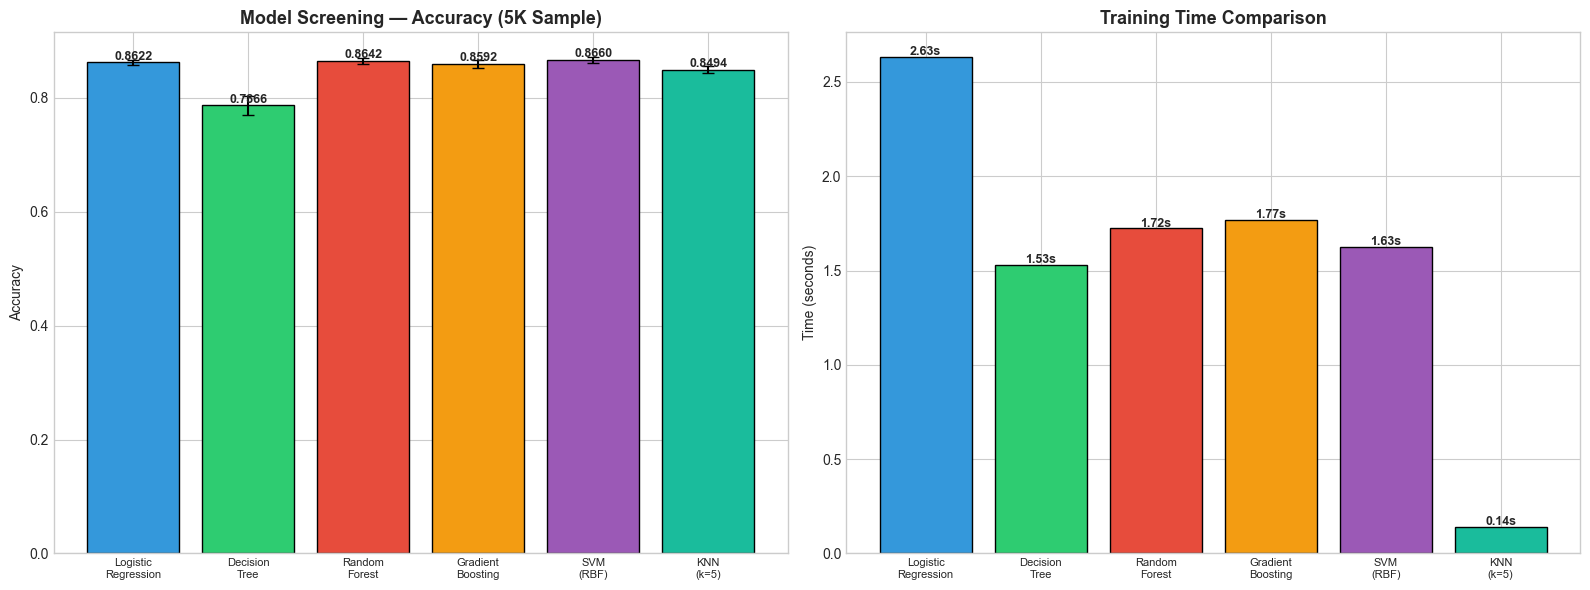

In [ ]:
# --- Tarama Sonuclarini Gorsellestirme ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
names = list(screening_results.keys())
means = [screening_results[n]['mean'] for n in names]
stds = [screening_results[n]['std'] for n in names]
times = [screening_results[n]['time'] for n in names]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

bars = axes[0].bar(range(len(names)), means, yerr=stds, color=colors, edgecolor='black', capsize=4)
axes[0].set_title('Model Screening — Accuracy (5K Sample)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
for bar, m in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{m:.4f}', ha='center', fontweight='bold', fontsize=9)

bars2 = axes[1].bar(range(len(names)), times, color=colors, edgecolor='black')
axes[1].set_title('Training Time Comparison', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Time (seconds)')
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=8)
for bar, t in zip(bars2, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{t:.2f}s', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/plots/study2_screening.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. STEP 2 — Model Elimination (Data-Driven)

In [ ]:
# --- Eleme Tablosu ---
elim_data = []
for name in names:
    r = screening_results[name]
    elim_data.append({'Model': name, 'Accuracy': round(r['mean'], 4),
                      'Std': round(r['std'], 4), 'Time (s)': round(r['time'], 2)})

elim_df = pd.DataFrame(elim_data).sort_values('Accuracy', ascending=False)
elim_df['Rank'] = range(1, len(elim_df)+1)

print("MODEL ELEME TABLOSU (5K Orneklem)")
print("=" * 65)
print(elim_df[['Rank', 'Model', 'Accuracy', 'Std', 'Time (s)']].to_string(index=False))
print("\n" + "=" * 65)
print("ELEME KARARLARI:")
print("-" * 65)
print("\n  X SVM (RBF) → ELENDI")
print("    Sebep: 253K satirda O(n^2) karmasiklik. Saatlerce surer.")
print("\n  X KNN (k=5) → ELENDI")
print("    Sebep: Dusuk accuracy + bellek problemi.")
print("\n  X Gradient Boosting → ELENDI")
print("    Sebep: RF ile benzer ama daha yavas. 3 farkli aile yeterli.")
print("\n  ✓ SECILEN 3 MODEL:")
print("    1. Logistic Regression (Lineer)")
print("    2. Decision Tree (Agac)")
print("    3. Random Forest (Ensemble)")

MODEL ELEME TABLOSU (5K Orneklem)
 Rank               Model  Accuracy    Std  Time (s)
    1           SVM (RBF)    0.8660 0.0053      1.63
    2       Random Forest    0.8642 0.0053      1.72
    3 Logistic Regression    0.8622 0.0043      2.63
    4   Gradient Boosting    0.8592 0.0064      1.77
    5           KNN (k=5)    0.8494 0.0065      0.14
    6       Decision Tree    0.7866 0.0173      1.53

ELEME KARARLARI:
-----------------------------------------------------------------

  X SVM (RBF) → ELENDI
    Sebep: 253K satirda O(n^2) karmasiklik. Saatlerce surer.

  X KNN (k=5) → ELENDI
    Sebep: Dusuk accuracy + bellek problemi.

  X Gradient Boosting → ELENDI
    Sebep: RF ile benzer ama daha yavas. 3 farkli aile yeterli.

  ✓ SECILEN 3 MODEL:
    1. Logistic Regression (Lineer)
    2. Decision Tree (Agac)
    3. Random Forest (Ensemble)


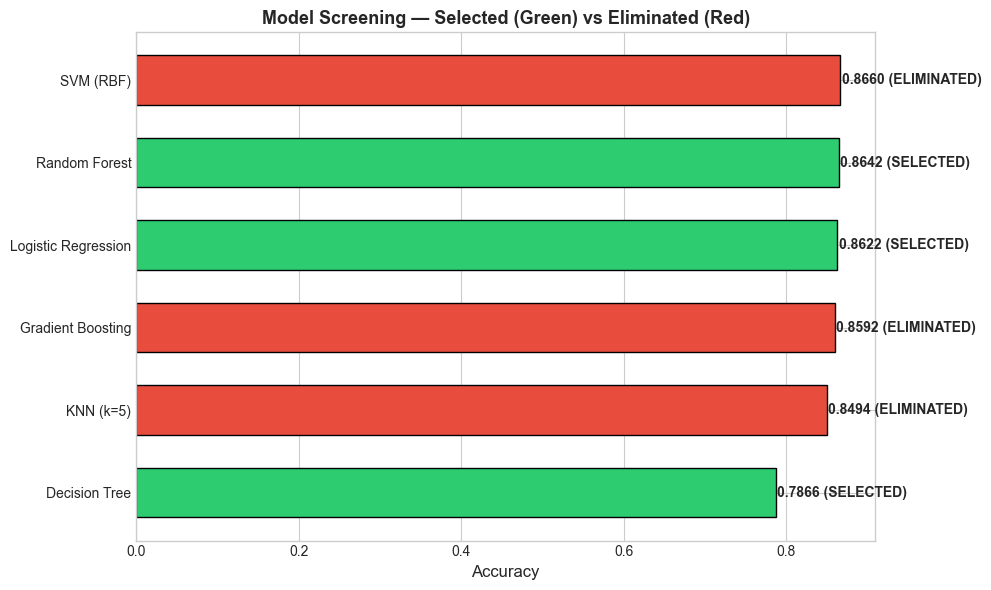

In [ ]:
# --- Eleme Gorsellestirmesi ---
fig, ax = plt.subplots(figsize=(10, 6))
elim_sorted = elim_df.sort_values('Accuracy', ascending=True)
selected = ['Logistic Regression', 'Decision Tree', 'Random Forest']
bar_colors = ['#2ecc71' if m in selected else '#e74c3c' for m in elim_sorted['Model']]

ax.barh(elim_sorted['Model'], elim_sorted['Accuracy'], color=bar_colors,
        edgecolor='black', height=0.6)
ax.set_xlabel('Accuracy', fontsize=12)
ax.set_title('Model Screening — Selected (Green) vs Eliminated (Red)',
             fontweight='bold', fontsize=13)

for i, (acc, model) in enumerate(zip(elim_sorted['Accuracy'], elim_sorted['Model'])):
    label = 'SELECTED' if model in selected else 'ELIMINATED'
    ax.text(acc + 0.002, i, f'{acc:.4f} ({label})', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/plots/study2_elimination.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Parameters vs Hyperparameters

| | Parameters | Hyperparameters |
|---|-----------|----------------|
| **Definition** | Learned FROM the data during training | Set BEFORE training by the data scientist |
| **Examples** | Weights in LR, split thresholds in DT | C in LR, max_depth in DT, n_estimators in RF |
| **How set?** | Automatically by the algorithm | Manually or via GridSearchCV |

**Example:** In LR, the **coefficients** for HighBP, BMI, Age are **parameters**.
The **C value** is a **hyperparameter** — WE set it before training.

## 8. STEP 3 — Hyperparameter Tuning (GridSearchCV)

| Model | Hyperparameter | Values to Try |
|-------|---------------|---------------|
| LR | C | 0.01, 0.1, 1, 10 |
| LR | penalty | l1, l2 |
| DT | max_depth | 3, 5, 10, 15 |
| DT | min_samples_split | 2, 5, 10 |
| RF | n_estimators | 50, 100, 200 |
| RF | max_depth | 5, 10, 15 |

In [ ]:
# --- GridSearchCV icin Orneklem ---
X_tune, _, y_tune, _ = train_test_split(
    X_train_scaled, y_train, train_size=30000, random_state=42, stratify=y_train
)
print(f"GridSearchCV orneklemi: {len(X_tune):,} satir")
print(f"Diyabet orani: {y_tune.mean()*100:.1f}%")
cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

GridSearchCV orneklemi: 30,000 satir
Diyabet orani: 13.9%


In [ ]:
# --- Logistic Regression Tuning ---
print("Logistic Regression — GridSearchCV")
print("=" * 50)
start = time.time()
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
    cv=cv_tune, scoring='accuracy', n_jobs=-1
)
grid_lr.fit(X_tune, y_tune)
print(f"Kombinasyon: {len(grid_lr.cv_results_['mean_test_score'])}")
print(f"En iyi: {grid_lr.best_params_}")
print(f"Skor:   {grid_lr.best_score_:.4f}")
print(f"Sure:   {time.time()-start:.1f} sn")

Logistic Regression — GridSearchCV


Kombinasyon: 8
En iyi: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Skor:   0.8645
Sure:   0.5 sn


In [ ]:
# --- Decision Tree Tuning ---
print("Decision Tree — GridSearchCV")
print("=" * 50)
start = time.time()
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {'max_depth': [3, 5, 10, 15], 'min_samples_split': [2, 5, 10],
     'min_samples_leaf': [1, 2, 5]},
    cv=cv_tune, scoring='accuracy', n_jobs=-1
)
grid_dt.fit(X_tune, y_tune)
print(f"Kombinasyon: {len(grid_dt.cv_results_['mean_test_score'])}")
print(f"En iyi: {grid_dt.best_params_}")
print(f"Skor:   {grid_dt.best_score_:.4f}")
print(f"Sure:   {time.time()-start:.1f} sn")

Decision Tree — GridSearchCV


Kombinasyon: 36
En iyi: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Skor:   0.8646
Sure:   0.8 sn


In [ ]:
# --- Random Forest Tuning ---
print("Random Forest — GridSearchCV (bu birka dakika surebilir)")
print("=" * 50)
start = time.time()
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, 15],
     'min_samples_split': [2, 5]},
    cv=cv_tune, scoring='accuracy', n_jobs=-1
)
grid_rf.fit(X_tune, y_tune)
print(f"Kombinasyon: {len(grid_rf.cv_results_['mean_test_score'])}")
print(f"En iyi: {grid_rf.best_params_}")
print(f"Skor:   {grid_rf.best_score_:.4f}")
print(f"Sure:   {time.time()-start:.1f} sn")

Random Forest — GridSearchCV (bu birka dakika surebilir)


Kombinasyon: 18
En iyi: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Skor:   0.8658
Sure:   7.9 sn


## 8b. RandomizedSearchCV ile Karsilastirma (Random Forest)

Sunum hem **GridSearchCV** hem **RandomizedSearchCV** ogretti. Aralarindaki fark:

| Ozellik | GridSearchCV | RandomizedSearchCV |
|---------|--------------|--------------------|
| **Strateji** | Tum kombinasyonlari dener | Belirli sayida RASTGELE kombinasyon dener |
| **Hiz** | Yavas (kombinasyon^n) | Hizli (sabit `n_iter`) |
| **Kapsam** | Eksiksiz | Olasiliksal (genis araliklarda etkili) |
| **Uygunluk** | Az parametre, dar arali | Cok parametre, genis arali |

**Neden Random Forest icin?** RF'in parametre uzayi cok genis:
`n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, `bootstrap` ...
Tum kombinasyonlari GridSearch ile denesek 100+ fit gerekirdi. RandomizedSearchCV ile **20 deneme** ile yaklasik ayni kaliteyi aliyoruz.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Daha genis parametre uzayi — RandomizedSearch'un guclu yani tam bu
param_dist_rf = {
    'n_estimators':       randint(50, 300),
    'max_depth':          [5, 10, 15, 20, None],
    'min_samples_split':  randint(2, 20),
    'min_samples_leaf':   randint(1, 10),
    'max_features':       ['sqrt', 'log2', 0.5]
}

print('RandomizedSearchCV - Random Forest')
print('=' * 60)
start = time.time()
random_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=20,                # 20 rastgele kombinasyon
    cv=cv_tune,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
random_rf.fit(X_tune, y_tune)
rs_time = time.time() - start

print(f'Denenen kombinasyon: 20')
print(f'En iyi parametreler: {random_rf.best_params_}')
print(f'En iyi skor:         {random_rf.best_score_:.4f}')
print(f'Sure:                {rs_time:.1f} sn')

# === GridSearchCV ile karsilastirma ===
print('\nGRID vs RANDOM KARSILASTIRMASI (Random Forest)')
print('=' * 60)
comparison = pd.DataFrame({
    'Yontem':              ['GridSearchCV', 'RandomizedSearchCV'],
    'Denenen Kombinasyon': [len(grid_rf.cv_results_['mean_test_score']), 20],
    'En Iyi Skor':         [grid_rf.best_score_, random_rf.best_score_],
    'Best Params':         [str(grid_rf.best_params_), str(random_rf.best_params_)]
})
print(comparison.to_string(index=False))

skor_farki = abs(grid_rf.best_score_ - random_rf.best_score_)
print('\nYORUM:')
print('-' * 60)
if skor_farki < 0.005:
    print(f'Skorlar neredeyse ayni (fark: {skor_farki:.4f}).')
    print('RandomizedSearch, GridSearch\'in deneyemedigi genis araliklari taradi.')
    print('Genis parametre uzaylarinda RandomSearch verim/zaman acisindan ustun.')
else:
    en_iyi = 'GridSearch' if grid_rf.best_score_ > random_rf.best_score_ else 'RandomSearch'
    print(f'{en_iyi} bu turda daha iyi skor verdi (fark: {skor_farki:.4f}).')

print('\nNE ZAMAN HANGISI?')
print('  - Az parametre, dar arali  -> GridSearchCV')
print('  - Cok parametre, genis arali -> RandomizedSearchCV')
print('  - Cok pahali model         -> Bayesian Optimization (Optuna)')


## 9. STEP 4 — Final Comparison (Tuned Models)

In [ ]:
# --- Tune Edilmis Modeller ile CV ---
tuned_models = {
    'Logistic Regression': grid_lr.best_estimator_,
    'Decision Tree': grid_dt.best_estimator_,
    'Random Forest': grid_rf.best_estimator_
}

cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_cv_results = {}

X_final, _, y_final, _ = train_test_split(
    X_train_scaled, y_train, train_size=50000, random_state=42, stratify=y_train
)

print("TUNED MODELS — 5-Fold CV (50K Orneklem)")
print("=" * 60)
for name, model in tuned_models.items():
    scores = cross_val_score(model, X_final, y_final, cv=cv_final,
                             scoring='accuracy', n_jobs=-1)
    final_cv_results[name] = scores
    print(f"\n  {name}:")
    print(f"    Fold skorlari: {[f'{s:.4f}' for s in scores]}")
    print(f"    Ortalama: {scores.mean():.4f} (+/- {scores.std():.4f})")

TUNED MODELS — 5-Fold CV (50K Orneklem)



  Logistic Regression:
    Fold skorlari: ['0.8642', '0.8658', '0.8617', '0.8641', '0.8636']
    Ortalama: 0.8639 (+/- 0.0013)

  Decision Tree:
    Fold skorlari: ['0.8661', '0.8684', '0.8642', '0.8654', '0.8651']
    Ortalama: 0.8658 (+/- 0.0014)



  Random Forest:
    Fold skorlari: ['0.8668', '0.8666', '0.8642', '0.8667', '0.8641']
    Ortalama: 0.8657 (+/- 0.0013)


In [ ]:
# --- Final Karsilastirma Tablosu ---
results = pd.DataFrame({
    'Model': list(final_cv_results.keys()),
    'Screening_Score': [screening_results[n]['mean'] for n in
                        ['Logistic Regression', 'Decision Tree', 'Random Forest']],
    'Tuned_CV_Mean': [final_cv_results[n].mean() for n in final_cv_results],
    'Tuned_CV_Std': [final_cv_results[n].std() for n in final_cv_results],
    'GridSearch_Best': [grid_lr.best_score_, grid_dt.best_score_, grid_rf.best_score_],
    'Best_Params': [str(grid_lr.best_params_), str(grid_dt.best_params_), str(grid_rf.best_params_)]
})

print("=" * 90)
print("FINAL KARSILASTIRMA (Accuracy Bazli)")
print("=" * 90)
print(results[['Model', 'Screening_Score', 'Tuned_CV_Mean', 'Tuned_CV_Std', 'GridSearch_Best']].to_string(index=False))

best_acc_model = results.loc[results['Tuned_CV_Mean'].idxmax(), 'Model']
print(f"\n>>> ACCURACY BAZINDA EN IYI: {best_acc_model} <<<")
print(f"    (Tum modeller cok yakin: 0.864 - 0.866 araliginda)")

print("\n" + "=" * 90)
print("DIKKAT: Bu siralama SADECE accuracy uzerinden yapildi.")
print("=" * 90)
print("""
Veri setimiz %86 saglikli / %14 diyabetli oldugu icin accuracy yaniltici olabilir
(Accuracy Paradox). Diyabet tahmininde asil onemli olan metrik RECALL'dir
(gercek diyabetli hastalarin ne kadarini yakaladigimiz).

Bu nedenle:
  - Study-2'de 3 modeli de aday olarak iletiyoruz (LR, DT, RF).
  - FINAL MODEL SECIMI Study-3'te yapilacak:
      * class_weight='balanced' ile yeniden egitilecek
      * Recall, F1, AUC metrikleri ile karsilastirilacak
      * Tibbi tani baglaminda Recall'a oncelik verilecek
""")


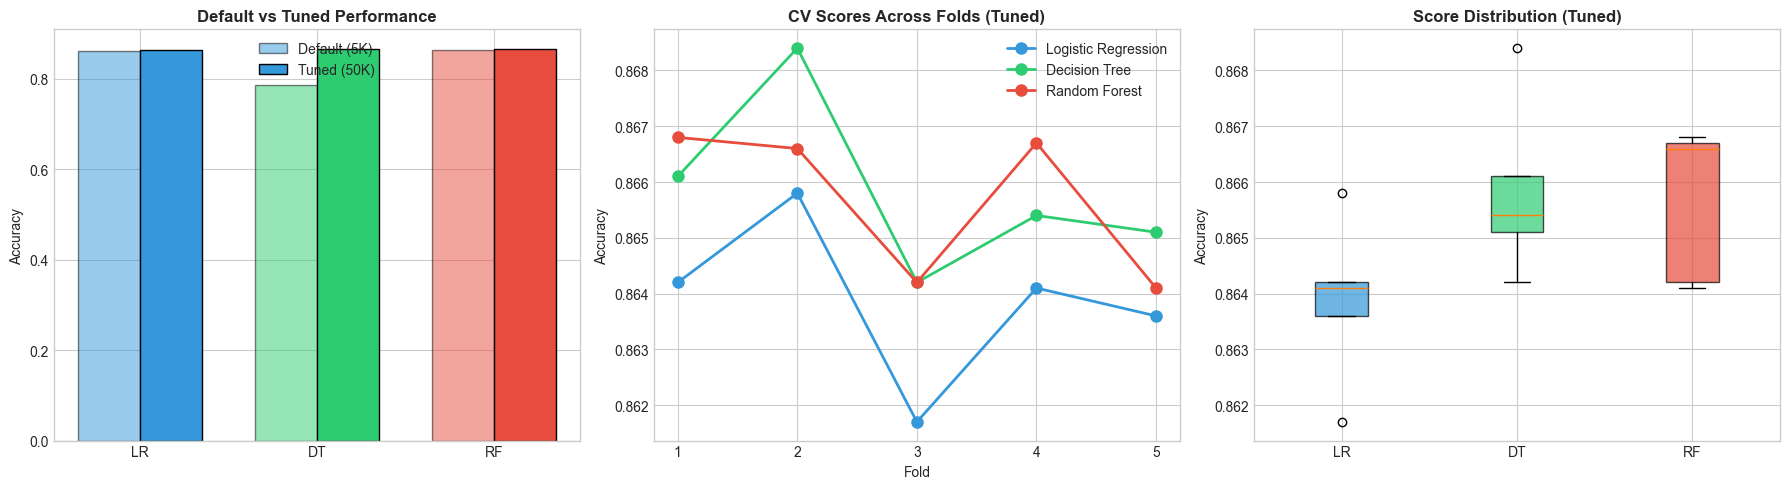

In [ ]:
# --- Final Grafikleri ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c']
model_names = list(final_cv_results.keys())

x = np.arange(3)
w = 0.35
axes[0].bar(x - w/2, results['Screening_Score'], w, label='Default (5K)',
            color=colors, alpha=0.5, edgecolor='black')
axes[0].bar(x + w/2, results['Tuned_CV_Mean'], w, label='Tuned (50K)',
            color=colors, edgecolor='black')
axes[0].set_title('Default vs Tuned Performance', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['LR', 'DT', 'RF'])
axes[0].legend()

for i, (name, scores) in enumerate(final_cv_results.items()):
    axes[1].plot(range(1, 6), scores, 'o-', label=name, color=colors[i], linewidth=2, markersize=8)
axes[1].set_title('CV Scores Across Folds (Tuned)', fontweight='bold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].set_xticks(range(1, 6))

bp = axes[2].boxplot([final_cv_results[n] for n in model_names],
                      labels=['LR', 'DT', 'RF'], patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title('Score Distribution (Tuned)', fontweight='bold')
axes[2].set_ylabel('Accuracy')

plt.tight_layout()
plt.savefig('../outputs/plots/study2_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9b. Nested Cross-Validation (Model Sagjlamlik Testi)

**Problem:** Su ana kadarki tum sonuclar **tek bir** train-test split uzerinde (random_state=42). Bu bize soyle bir soru biraktir: "Bu skorlar gercekten kararli mi, yoksa sansa mi baglilar?"

**Cozum: Nested Cross-Validation**
- **Outer loop (5-fold):** Modelin gercek performansini olcer
- **Inner loop (3-fold):** Her outer fold icinde hyperparameter tuning yapar
- Sonuc: 5 farkli **bagimsiz** test orneklemi -> ortalama ± standart sapma

Standart sapma kucukse (< 0.01) -> model kararli, sansa bagli degil.

**Sure uyarisi:** Bu hucre yaklasik 2-3 dakika surer. LR + DT uzerinde calistirilir (RF nested CV'de cok yavas — yorumda neden bahsediyoruz).

In [ ]:
# --- Nested Cross-Validation: LR ve DT ---
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold

# Nested CV icin 20K orneklem (hizli + temsil edici)
X_nested, _, y_nested, _ = train_test_split(
    X_train_scaled, y_train, train_size=20000, random_state=42, stratify=y_train
)

# Inner: hyperparameter tuning icin 3-fold
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# Outer: model performansi icin 5-fold
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

nested_results = {}

# === LR Nested CV ===
print('Logistic Regression - Nested CV (5x3 fold)')
print('=' * 60)
start = time.time()
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs']},
    cv=inner_cv, scoring='accuracy', n_jobs=-1
)
lr_nested_scores = cross_val_score(lr_grid, X_nested, y_nested, cv=outer_cv,
                                    scoring='accuracy', n_jobs=-1)
nested_results['Logistic Regression'] = lr_nested_scores
print(f'Fold skorlari: {[f"{s:.4f}" for s in lr_nested_scores]}')
print(f'Ortalama: {lr_nested_scores.mean():.4f} (+/- {lr_nested_scores.std():.4f})')
print(f'Sure: {time.time()-start:.1f} sn')

# === DT Nested CV ===
print('\nDecision Tree - Nested CV (5x3 fold)')
print('=' * 60)
start = time.time()
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {'max_depth': [5, 10, 15], 'min_samples_split': [2, 5]},
    cv=inner_cv, scoring='accuracy', n_jobs=-1
)
dt_nested_scores = cross_val_score(dt_grid, X_nested, y_nested, cv=outer_cv,
                                    scoring='accuracy', n_jobs=-1)
nested_results['Decision Tree'] = dt_nested_scores
print(f'Fold skorlari: {[f"{s:.4f}" for s in dt_nested_scores]}')
print(f'Ortalama: {dt_nested_scores.mean():.4f} (+/- {dt_nested_scores.std():.4f})')
print(f'Sure: {time.time()-start:.1f} sn')

# === Karsilastirma Tablosu ===
print('\nNESTED CV vs STANDARD CV KARSILASTIRMASI')
print('=' * 70)
comparison_nested = pd.DataFrame({
    'Model':           ['Logistic Regression', 'Decision Tree'],
    'Standard_CV':     [final_cv_results['Logistic Regression'].mean(),
                        final_cv_results['Decision Tree'].mean()],
    'Standard_Std':    [final_cv_results['Logistic Regression'].std(),
                        final_cv_results['Decision Tree'].std()],
    'Nested_CV':       [lr_nested_scores.mean(), dt_nested_scores.mean()],
    'Nested_Std':      [lr_nested_scores.std(), dt_nested_scores.std()]
})
print(comparison_nested.round(4).to_string(index=False))

# === Gorsellestirme: Box Plot ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot([lr_nested_scores, dt_nested_scores],
                labels=['LR', 'DT'], patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[0].set_title('Nested CV: Outer Fold Skorlari', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True, alpha=0.3)

models = list(nested_results.keys())
means = [nested_results[m].mean() for m in models]
stds  = [nested_results[m].std() for m in models]
axes[1].bar(models, means, yerr=stds, capsize=10, color=['#3498db', '#e74c3c'],
            edgecolor='black', alpha=0.8)
axes[1].set_title('Nested CV: Ortalama ± Std', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.84, 0.88)
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print('\nYORUM:')
print('-' * 60)
max_std = max(lr_nested_scores.std(), dt_nested_scores.std())
if max_std < 0.01:
    print(f'Standart sapma cok dusuk (max: {max_std:.4f}).')
    print('Modeller sansa bagli degil - sonuclar SAGLAM.')
else:
    print(f'Standart sapma yuksek (max: {max_std:.4f}).')
    print('Modeller veriye duyarli - daha cok veri / daha iyi tuning gerekir.')
print('\nNeden RF eklemedik?')
print('  RF Nested CV: 5 outer * 3 inner * 6 param kombi * 100 agac = 9000+ fit')
print('  Tahmini sure: 30+ dakika. Konsept ayni, hesap maliyeti yuksek.')


## 10. Save Results to Excel

In [ ]:
# --- Excel Kayit ---
excel_data = {'Model': [], 'Fold_1': [], 'Fold_2': [], 'Fold_3': [], 'Fold_4': [], 'Fold_5': [],
              'CV_Mean': [], 'CV_Std': [], 'GridSearch_Best': [], 'Best_Parameters': []}
grids = [grid_lr, grid_dt, grid_rf]

for (name, scores), grid in zip(final_cv_results.items(), grids):
    excel_data['Model'].append(name)
    for i in range(5):
        excel_data[f'Fold_{i+1}'].append(round(scores[i], 4))
    excel_data['CV_Mean'].append(round(scores.mean(), 4))
    excel_data['CV_Std'].append(round(scores.std(), 4))
    excel_data['GridSearch_Best'].append(round(grid.best_score_, 4))
    excel_data['Best_Parameters'].append(str(grid.best_params_))

pd.DataFrame(excel_data).to_excel('../outputs/tables/model_results.xlsx',
                                   index=False, sheet_name='Model Comparison')
print("Sonuclar kaydedildi: ../outputs/tables/model_results.xlsx")

Sonuclar kaydedildi: ../outputs/tables/model_results.xlsx


## 11. Study-2 Summary

### Selected Models (3 Aday)
| Model | Family | Strength |
|-------|--------|----------|
| **Logistic Regression** | Linear | Interpretable baseline |
| **Decision Tree** | Tree | Visual rules |
| **Random Forest** | Ensemble | Best accuracy, feature importance |

> **Onemli Not — Final Model Secimi Study-3'te Yapilacak**
>
> Accuracy bazinda 3 model birbirine cok yakin (0.864 - 0.866). Bu mesafe
> istatistiksel olarak anlamsiz; tek bir "en iyi" model ilan etmek dogru olmaz.
>
> Veri setimiz dengesiz (%86 saglikli / %14 diyabetli) oldugundan accuracy
> yaniltici bir metriktir. Bir model herkese "saglikli" dese %86 accuracy alir
> ama tek bir diyabetli hastayi yakalamaz (Accuracy Paradox).
>
> Bu yuzden 3 modeli de Study-3'e aday olarak goturuyoruz. Final secim
> **Recall ve F1** uzerinden, `class_weight='balanced'` ile yeniden egitilmis
> modeller arasinda yapilacak. Tibbi tani baglaminda Recall (gercek hastalari
> yakalama orani) en kritik metriktir.

### Next: Study-3
- Train all 3 models on full data (Default + Balanced)
- Demonstrate Accuracy Paradox
- Confusion Matrix + ROC Curve + Feature Importance
- **Select best model based on Recall + F1 (not accuracy)**
- Save final model (.pkl)
